## 1. Import data from Factor Model

In [38]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [39]:
t_eval = np.load('data/t_eval.npy', allow_pickle = True)
returns = pd.read_csv('data/returns.csv', index_col = 0, parse_dates = True)

print(len(t_eval))
returns


83


,AAPL,ABBV,AEP,AMT,AMZN,APD,AVGO,BAC,BLK,CAT,...,SLB,SO,SPG,T,TSLA,UNH,UNP,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2013-02-01,-0.031422,0.018084,0.032583,0.018862,-0.004644,-0.012545,-0.044299,-0.007982,0.014579,-0.063137,...,-0.002566,0.028546,-0.008275,0.048665,-0.074129,-0.032398,0.042081,0.014265,0.011796,-0.004679
2013-03-01,0.008662,0.099438,0.049106,-0.008801,0.008365,0.008994,0.048484,0.082105,0.069012,-0.060239,...,-0.034919,0.041559,0.005168,0.021488,0.084208,0.067982,0.043122,0.053017,0.055642,0.012602
2013-04-01,0.000271,0.121536,0.055981,0.087932,-0.048751,0.006270,-0.111507,0.010616,0.043753,-0.026802,...,-0.006161,0.027537,0.116044,0.020769,0.354112,0.050323,0.038231,0.026412,0.044325,-0.012507
2013-05-01,0.015574,-0.066551,-0.115501,-0.072696,0.058869,0.082199,0.165970,0.104060,0.046554,0.019661,...,-0.018989,-0.094067,-0.067542,-0.052416,0.593717,0.044067,0.044029,0.065476,-0.037761,0.016494
2013-06-01,-0.119299,-0.032134,-0.013318,-0.061870,0.031051,-0.030544,-0.009320,-0.060350,-0.083436,-0.039341,...,-0.018937,0.015880,-0.046109,0.011649,0.093672,0.044500,0.002182,0.025443,0.001293,0.005566
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,0.030684,0.066755,0.021775,0.016470,-0.046413,0.062176,0.013231,0.010856,0.028467,0.032259,...,-0.093262,0.033902,0.086778,0.048106,-0.080549,0.024076,0.037234,-0.014770,0.117912,-0.005496
2024-09-01,0.018473,0.005942,0.031888,0.037234,0.042931,0.065547,0.057752,-0.026609,0.051542,0.093803,...,-0.047484,0.051096,0.009930,0.100323,0.200441,-0.009397,-0.032942,-0.026840,0.047416,0.001895
2024-10-01,-0.030902,0.031845,-0.038246,-0.085324,0.000376,0.042060,-0.012669,0.059026,0.038557,-0.038893,...,-0.039327,0.009381,0.013132,0.024249,-0.046071,-0.031585,-0.060242,0.139092,0.014751,-0.003761


## 2. PCA and Covariance Estimation

In [40]:
from sklearn.decomposition import PCA

lookback = 36
window = returns.iloc[-lookback-1:-1]
pca = PCA()
pca.fit(window)
variance_pct = pca.explained_variance_ratio_
cum_var = np.cumsum(variance_pct)
k = np.argmax(cum_var >= 0.8) + 1

Text(0.5, 1.0, 'Cross-Sectional Cumulative Variance')

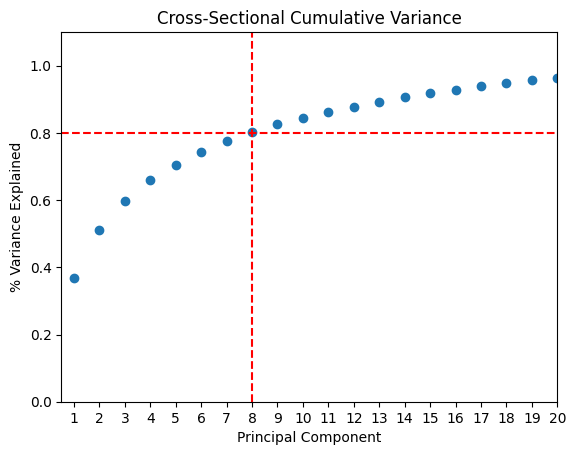

In [41]:

plt.scatter(range(1, 1 + len(cum_var)), cum_var)
plt.axhline(0.8, color = 'r', ls = '--')
plt.axvline(k, color = 'r', ls = '--')
plt.xlim(0.5,20)
plt.ylim(0,1.1)
plt.xticks(np.linspace(1,20,20))
plt.xlabel('Principal Component')
plt.ylabel('% Variance Explained')
plt.title('Cross-Sectional Cumulative Variance')



In [42]:
from sklearn.decomposition import PCA

lookback = 36
threshold = 0.8
Sigma = {}

for t in range(lookback, len(returns)):

    # Lookback window
    window = returns.iloc[t-lookback:t]

    # PCA deconstruction
    pca = PCA()
    pca.fit(window)

    cum_var = np.cumsum(pca.explained_variance_ratio_)
    k = np.argmax(cum_var >= 0.8)

    B = pca.components_[:k,:]
    F = np.diag(pca.explained_variance_[:k])

    Sigma_pca = B.T @ F @ B

    sample_cov = window.cov().values

    D = np.diag(np.diag(sample_cov - Sigma_pca))

    Sigma_t = Sigma_pca + D

    Sigma[returns.index[t]] = Sigma_t




## 3. Mean-Variance Optimisation

In [48]:
scores = pd.read_csv('data/factor_scores.csv', index_col = 0, parse_dates = True)
scores

,AAPL,MSFT,NVDA,AVGO,CRM,JPM,BAC,GS,MS,BLK,...,PLD,AMT,EQIX,SPG,PSA,LIN,APD,NEM,FCX,SHW
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,0.285924,0.176170,2.691083,0.573613,0.510392,0.242664,0.534564,0.271445,0.434540,0.342693,...,-0.220225,0.047586,-0.026582,-0.495423,-0.569212,-0.144772,-0.188472,-0.083798,1.734558,0.390573
2018-02-01,-0.061881,0.052744,2.329458,0.287268,0.289686,0.112970,0.311693,0.076597,0.227630,0.269786,...,-0.083767,0.027838,0.277437,-0.417882,-0.624995,-0.032055,-0.141562,-0.034822,1.135665,0.279118
2018-03-01,-0.182815,0.223865,2.303349,0.096067,0.047078,0.158996,0.428379,-0.000035,0.147826,0.137342,...,0.007629,-0.057475,0.385634,-0.427716,-0.547284,-0.116625,-0.269943,-0.139705,0.611090,0.110283
2018-04-01,-0.007612,0.266283,2.423315,0.083315,0.025184,0.137524,0.427476,-0.044002,0.126796,0.115312,...,-0.166178,-0.061977,0.195809,-0.523359,-0.725784,-0.156342,-0.405465,-0.148275,0.922213,0.069119
2018-05-01,0.208287,0.157566,2.088080,0.262880,-0.043337,0.024200,0.408086,-0.149404,0.041803,0.029886,...,-0.123085,-0.070472,0.163488,-0.617544,-0.835746,-0.223178,-0.524051,-0.318605,1.118532,0.084576
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-01,-0.063842,0.009303,0.999391,0.512933,0.079336,-0.008625,-0.027162,0.006557,0.140746,-0.173745,...,0.114836,0.065009,-0.221267,-0.106885,-0.103534,-0.225419,-0.366204,0.346108,0.192533,0.081354
2024-08-01,0.001408,0.019113,1.031300,0.471137,0.297287,-0.155147,-0.152869,-0.122960,0.161193,-0.006708,...,0.352126,0.222917,-0.094173,-0.134776,0.134956,-0.269966,-0.266403,0.384152,0.217711,0.193071
2024-09-01,0.130805,0.172721,1.284392,0.647153,0.231767,0.071559,-0.138593,-0.020627,0.145017,-0.097425,...,0.271769,0.091409,-0.212608,-0.253765,0.016573,-0.268337,-0.350317,0.304740,0.187224,0.157842
